# Reconstructed rate maps

## Good example cells (cmGC) from XGBoost OF assay

| Mouse | Day | Cell | pos pR² | full_beh pR² | pos+10GC pR² | Notes |
|-------|-----|------|---------|-------------|-------------|-------|
| **25** | **21** | **108** | **0.284** | **0.397** | **0.315** | **Best position encoding — used here** |
| 25 | 18 | 7 | 0.209 | 0.295 | — | Runner-up by pos pR² |
| 25 | 20 | 129 | 0.172 | 0.223 | 0.293 | Largest ΔpR² from adding GC cells |
| 25 | 24 | 112 | 0.192 | 0.196 | 0.221 | Almost entirely position-explained |
| 21 | 23 | 277 | 0.172 | 0.295 | — | Strong HD conjunction |

## Notebook structure

**Sanity check** (cell 4): rate map with vs without position bias correction.

**Main figure** (cells 5–6): 9 models × 4 rows.
- Row 1: Reconstructed 2D rate maps
- Row 2: Head direction tuning
- Row 3: Speed tuning
- Row 4: Theta/LFP tuning

Models: `True | Pos | HD | Speed | LFP | P+HD+S+LFP | 10 GC cells | 10 NGS cells | P+HD+S+LFP+10GC`

`10 GC cells` = GC spike trains only (no explicit position) — tests whether GC ensemble
activity implicitly encodes the target cell's spatial firing.

`10 NGS cells` = non-grid spatial cell spike trains only — comparison for whether the
spatial encoding is specific to grid cells or shared across spatial cell types.

In [1]:
import sys
sys.path.insert(0, '/Users/harryclark/Documents/spatial-manifolds/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde as scipy_kde
import pynapple as nap
import os, warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['font.family'] = 'Arial'

from spatial_manifolds.detect_grids import (
    compute_of_tcs, classify_cells_both_sessions, get_theta_trace, time_bs
)
from spatial_manifolds.predictive_grid import compute_travel_projected
from spatial_manifolds.mlencoding import MLencoding

MOUSE     = 25
DAY       = 20
TARGET_ID = 129
SESSION   = 'OF1'
N_COV     = 10
N_BINS_2D = 40
N_BINS_1D = 30
SIGMA_2D  = 2.0

source_path = '/Users/harryclark/Downloads/COHORT12/'
fig_path    = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
print('Config ready.')

Config ready.


In [2]:
brain_locations = pd.read_csv(source_path + 'all_cluster_brain_locations_chris.csv')

spatial_ms = (f'{source_path}M{MOUSE}/D{DAY:02}/{SESSION}/'
              'tuning_scores/shifted_spatial_information_manual_smooth.parquet')
spatial_ns = (f'{source_path}M{MOUSE}/D{DAY:02}/{SESSION}/'
              'tuning_scores/shifted_spatial_information.parquet')
fpath = spatial_ms if os.path.exists(spatial_ms) else spatial_ns

df_si     = pd.read_parquet(fpath)
score_col = ('spatial_information' if 'spatial_information' in df_si.columns
             else [c for c in df_si.columns
                   if c not in ('cluster_id', 'travel', 'sig', 'brain_region')][0])
cluster_ids = df_si[df_si['travel'] == 0]['cluster_id'].values

travel_at_max = []
for cid in cluster_ids:
    br = brain_locations[
        (brain_locations['mouse'] == MOUSE) & (brain_locations['day'] == DAY) &
        (brain_locations['cluster_id'] == cid)
    ]
    if br.empty: continue
    if not any(r in br['brain_region'].iloc[0] for r in ['ENT', 'PAR', 'PRE']): continue
    cell_df = df_si[df_si['cluster_id'] == cid]
    scores  = np.array(cell_df[score_col])
    travels = np.array(cell_df['travel'])
    if len(scores) == 0 or np.all(np.isnan(scores)): continue
    travel_at_max.append(travels[np.nanargmax(scores)])

if len(travel_at_max) > 3:
    kde = scipy_kde(travel_at_max, bw_method=0.3)
    x = np.linspace(-50, 50, 1000)
    optimal_shift = float(x[np.argmax(kde(x))])
    if optimal_shift < -30:
        optimal_shift = 0.0
else:
    optimal_shift = 0.0

print(f'Optimal shift: {optimal_shift:.2f} cm  ({len(travel_at_max)} ENT/PAR/PRE cells in KDE)')

Optimal shift: 8.86 cm  (64 ENT/PAR/PRE cells in KDE)


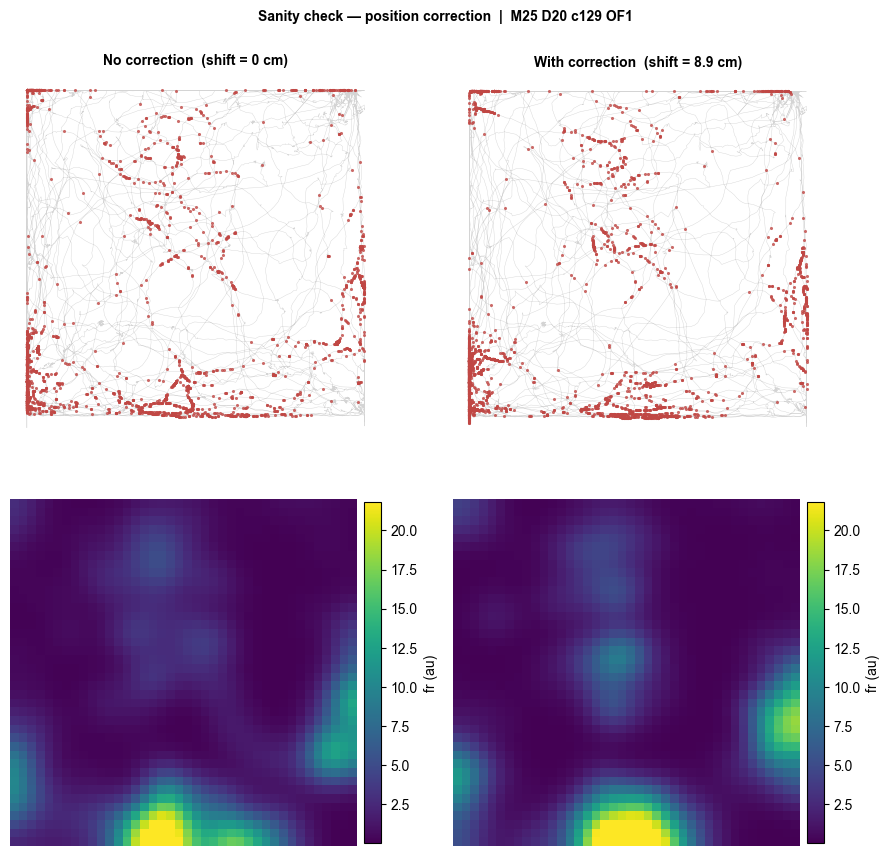

In [3]:
def smooth_nan(arr, sigma=SIGMA_2D):
    mask   = np.isnan(arr)
    filled = arr.copy(); filled[mask] = 0.0
    s = gaussian_filter(filled.astype(float), sigma=sigma)
    w = gaussian_filter((~mask).astype(float), sigma=sigma)
    with np.errstate(invalid='ignore'):
        result = s / w
    result[w < 0.05] = np.nan
    return result

# Load without correction — keep beh_OF, clusters_OF, tcs_time for later cells
tcs_raw, tcs_time, beh_OF, clusters_OF, ep = compute_of_tcs(
    MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False,
    fill_nans_from_neighbors=True, source_path=source_path,
    session=SESSION, optimal_shift=0)

# Load with correction — only need tcs for target cell sanity check
tcs_corr, _, _, _, _ = compute_of_tcs(
    MOUSE, DAY, apply_zscore=False, apply_guassian_filter=False,
    fill_nans_from_neighbors=True, source_path=source_path,
    session=SESSION, optimal_shift=optimal_shift)

tc_no  = smooth_nan(np.array(tcs_raw[TARGET_ID]))
tc_yes = smooth_nan(np.array(tcs_corr[TARGET_ID]))
vmax   = np.nanpercentile(np.concatenate([tc_no.ravel(), tc_yes.ravel()]), 99)
vmin   = np.nanmin(np.concatenate([tc_no.ravel(), tc_yes.ravel()]))

# ── Spike positions for trajectory row ───────────────────────────────────────
spike_times = clusters_OF[TARGET_ID].times()

raw_t  = np.array(beh_OF['P_x'].times())
raw_px = np.array(beh_OF['P_x'])
raw_py = np.array(beh_OF['P_y'])
spk_x_raw = np.interp(spike_times, raw_t, raw_px)
spk_y_raw = np.interp(spike_times, raw_t, raw_py)

if optimal_shift != 0.0:
    position = np.stack([beh_OF['P_x'], beh_OF['P_y']], axis=1)
    beh_lag_sanity = compute_travel_projected(["P_x", "P_y"], position, position, optimal_shift)
    corr_t  = np.array(beh_lag_sanity['P_x'].times())
    corr_px = np.array(beh_lag_sanity['P_x'])
    corr_py = np.array(beh_lag_sanity['P_y'])
    spk_x_corr = np.interp(spike_times, corr_t, corr_px)
    spk_y_corr = np.interp(spike_times, corr_t, corr_py)
else:
    corr_px, corr_py = raw_px, raw_py
    spk_x_corr, spk_y_corr = spk_x_raw, spk_y_raw

# ── Plot 2 rows × 2 cols ─────────────────────────────────────────────────────
TITLES = ['No correction  (shift = 0 cm)',
          f'With correction  (shift = {optimal_shift:.1f} cm)']

fig, axes = plt.subplots(2, 2, figsize=(9, 9))

# Row 0: trajectory + spikes
for col, (traj_x, traj_y, spk_x, spk_y) in enumerate([
        (raw_px,  raw_py,  spk_x_raw,  spk_y_raw),
        (corr_px, corr_py, spk_x_corr, spk_y_corr)]):
    ax = axes[0, col]
    ax.plot(traj_x, traj_y, color='#aaaaaa', lw=0.3, alpha=0.5, zorder=1)
    ax.scatter(spk_x, spk_y, c='#c04744', s=5, alpha=0.8, linewidths=0, zorder=2)
    ax.set_aspect('equal')
    ax.set_title(TITLES[col], fontsize=10, fontweight='bold')
    ax.axis('off')
    if col == 0:
        ax.set_ylabel('Trajectory + spikes', fontsize=8)

# Row 1: rate maps
for col, tc in enumerate([tc_no, tc_yes]):
    ax = axes[1, col]
    im = ax.imshow(tc.T, origin='lower', aspect='equal',
                   cmap='viridis', vmin=vmin, vmax=vmax)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label='fr (au)')
    if col == 0:
        ax.set_ylabel('Rate map', fontsize=8)

fig.suptitle(f'Sanity check — position correction  |  M{MOUSE} D{DAY} c{TARGET_ID} {SESSION}',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_path + f'ratemap_sanity_M{MOUSE}D{DAY}_c{TARGET_ID}.pdf',
            bbox_inches='tight', dpi=200)
plt.show()

In [4]:
last_t = clusters_OF[clusters_OF.index[0]].count(bin_size=time_bs, time_units='ms').index[-1]
ep2    = nap.IntervalSet(start=0, end=last_t, time_units='s')

y = np.array(tcs_time[TARGET_ID])
T = len(y)

def _bin(sig):
    a = np.array(sig.bin_average(bin_size=time_bs, time_units='ms', ep=ep2))[:T]
    return pd.Series(a).ffill().bfill().to_numpy()

# Position with correction applied
if optimal_shift != 0.0:
    position = np.stack([beh_OF['P_x'], beh_OF['P_y']], axis=1)
    beh_lag  = compute_travel_projected(["P_x", "P_y"], position, position, optimal_shift)
    pos_x = _bin(beh_lag['P_x'])
    pos_y = _bin(beh_lag['P_y'])
else:
    pos_x = _bin(beh_OF['P_x'])
    pos_y = _bin(beh_OF['P_y'])

speed = _bin(beh_OF['S'])
hd    = _bin(beh_OF['H'])

try:
    theta = np.array(get_theta_trace(MOUSE, DAY, TARGET_ID, time_bs=50,
                                      resample_bs=time_bs, session_type=SESSION,
                                      source_path=source_path))
    theta = theta[:T] if len(theta) >= T else np.pad(theta, (0, T - len(theta)))
except Exception as e:
    print(f'Theta unavailable ({e}) — using zeros.')
    theta = np.zeros(T)

# Covariate cell pools
gcs, ngs, _ = classify_cells_both_sessions(MOUSE, DAY, percentile_threshold=95,
                                            source_path=source_path)
cov_gc_ids  = [c for c in gcs['cluster_id'].values
               if c != TARGET_ID and c in tcs_time][:N_COV]
cov_ngs_ids = [c for c in ngs['cluster_id'].values
               if c != TARGET_ID and c in tcs_time][:N_COV]

cov_gc_mat  = np.vstack([np.array(tcs_time[c])[:T] for c in cov_gc_ids]).T
cov_ngs_mat = np.vstack([np.array(tcs_time[c])[:T] for c in cov_ngs_ids]).T
print(f'GC covariate cells  ({len(cov_gc_ids)}): {cov_gc_ids}')
print(f'NGS covariate cells ({len(cov_ngs_ids)}): {cov_ngs_ids}')

xgb = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                 window=time_bs, n_filters=5, max_time=1000)

MODELS = {
    'True':              None,
    'Pos':               np.column_stack([pos_x, pos_y]),
    'HD':                hd[:, None],
    'Speed':             speed[:, None],
    'LFP':               theta[:, None],
    'P+HD+S+LFP':       np.column_stack([pos_x, pos_y, hd, speed, theta]),
    '10 GC cells':      cov_gc_mat,
    '10 NGS cells':     cov_ngs_mat,
    'P+HD+S+LFP+10GC': np.column_stack([pos_x, pos_y, hd, speed, theta, cov_gc_mat]),
}

predictions = {}
pr2_vals    = {}
for name, X in MODELS.items():
    if X is None:
        predictions[name] = y.astype(float)
        pr2_vals[name]    = np.nan
    else:
        Y_hat, pR2 = xgb.fit_cv(X, y, verbose=0, continuous_folds=True)
        predictions[name] = np.array(Y_hat)
        pr2_vals[name]    = float(np.nanmean(pR2))
        print(f'  {name:20s}  pR² = {pr2_vals[name]:.4f}')

print('\nAll models fitted.')

Theta unavailable (File /Users/harryclark/Downloads/COHORT12/LFP/M25/D20/OF1/sub-M25_ses-D20_typ-OF1_lfp.npz does not exist) — using zeros.
GC covariate cells  (10): [111, 120, 126, 133, 137, 140, 146, 149, 156, 159]
NGS covariate cells (10): [114, 121, 122, 123, 127, 132, 134, 143, 145, 152]
  Pos                   pR² = 0.2149
  HD                    pR² = -0.0321
  Speed                 pR² = -0.0120
  LFP                   pR² = 0.0001
  P+HD+S+LFP            pR² = 0.2138
  10 GC cells           pR² = 0.3222
  10 NGS cells          pR² = 0.1026
  P+HD+S+LFP+10GC       pR² = 0.3685

All models fitted.


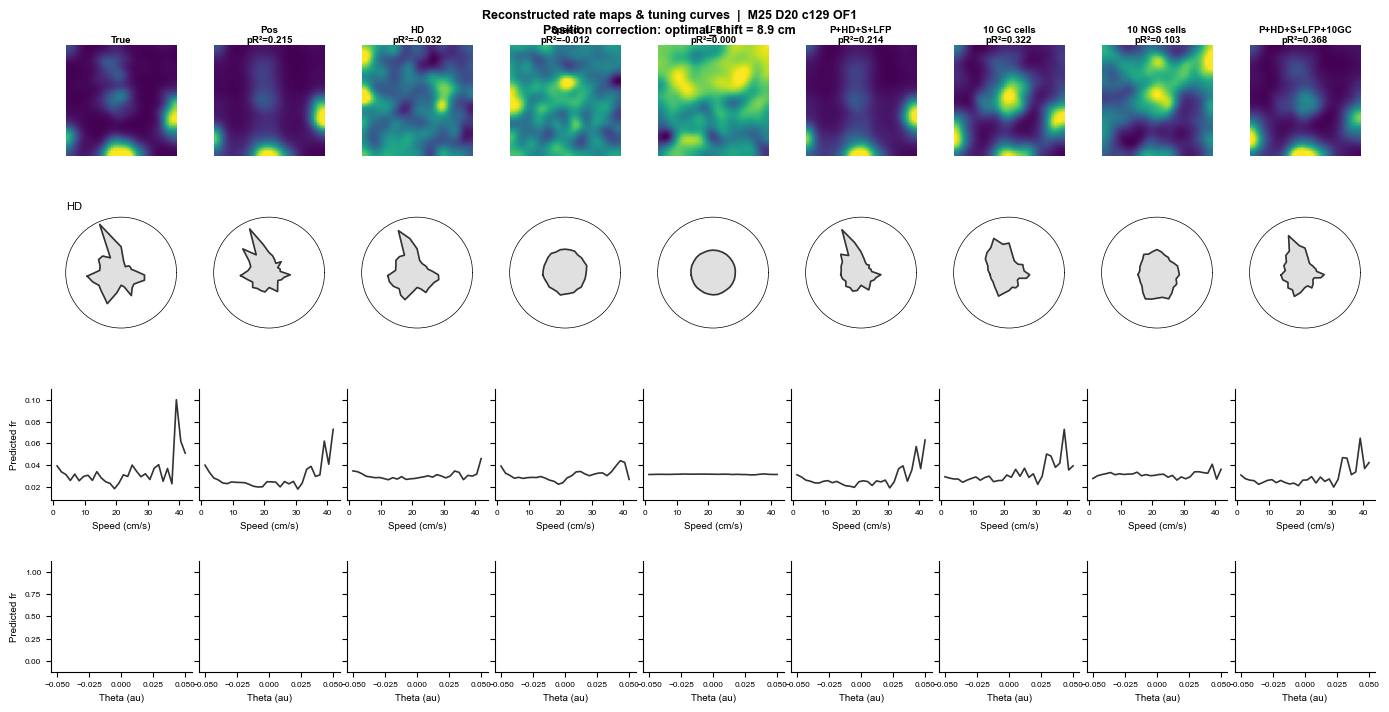

Saved.


In [5]:
MODEL_NAMES = list(MODELS.keys())
N_MODELS    = len(MODEL_NAMES)

def make_rate_map(pred, px, py):
    x_bins = np.linspace(np.nanpercentile(px, 1), np.nanpercentile(px, 99), N_BINS_2D + 1)
    y_bins = np.linspace(np.nanpercentile(py, 1), np.nanpercentile(py, 99), N_BINS_2D + 1)
    spk, _, _ = np.histogram2d(px, py, bins=[x_bins, y_bins], weights=pred)
    occ, _, _ = np.histogram2d(px, py, bins=[x_bins, y_bins])
    with np.errstate(invalid='ignore', divide='ignore'):
        rm = np.where(occ > 2, spk / occ, np.nan)
    return smooth_nan(rm, sigma=SIGMA_2D)

def make_1d_tc(pred, cov):
    edges   = np.linspace(np.nanpercentile(cov, 1), np.nanpercentile(cov, 99), N_BINS_1D + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    means   = np.array([
        np.nanmean(pred[(cov >= edges[i]) & (cov < edges[i+1])])
        if ((cov >= edges[i]) & (cov < edges[i+1])).sum() > 2 else np.nan
        for i in range(N_BINS_1D)
    ])
    return centers, means

def make_hd_tc(pred, hd_rad):
    edges   = np.linspace(-np.pi, np.pi, N_BINS_1D + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    means   = np.array([
        np.nanmean(pred[(hd_rad >= edges[i]) & (hd_rad < edges[i+1])])
        if ((hd_rad >= edges[i]) & (hd_rad < edges[i+1])).sum() > 2 else np.nan
        for i in range(N_BINS_1D)
    ])
    return centers, means

# Precompute all panels
rate_maps = {n: make_rate_map(predictions[n], pos_x, pos_y) for n in MODEL_NAMES}
hd_tcs    = {n: make_hd_tc(predictions[n], hd)    for n in MODEL_NAMES}
spd_tcs   = {n: make_1d_tc(predictions[n], speed)  for n in MODEL_NAMES}
lfp_tcs   = {n: make_1d_tc(predictions[n], theta)  for n in MODEL_NAMES}

ROW_DATA  = [hd_tcs,  spd_tcs,       lfp_tcs]
ROW_XLABS = ['HD',    'Speed (cm/s)', 'Theta (au)']
ROW_POLAR = [True,    False,          False]

fig = plt.figure(figsize=(N_MODELS * 1.6, 4 * 1.8))
gs  = gridspec.GridSpec(4, N_MODELS, figure=fig,
                        hspace=0.55, wspace=0.05,
                        left=0.07, right=0.99, top=0.93, bottom=0.06)

# Row 0: 2D rate maps (viridis, vmin=nanmin, vmax=99th pctile)
for ci, name in enumerate(MODEL_NAMES):
    ax  = fig.add_subplot(gs[0, ci])
    rm  = rate_maps[name]
    if not np.all(np.isnan(rm)):
        vmin_rm = float(np.nanmin(rm))
        vmax_rm = float(np.nanpercentile(rm, 99))
    else:
        vmin_rm, vmax_rm = 0.0, 1.0
    ax.imshow(rm.T, origin='lower', aspect='equal',
              cmap='viridis', vmin=vmin_rm, vmax=vmax_rm)
    pR2_str = f'\npR²={pr2_vals[name]:.3f}' if not np.isnan(pr2_vals[name]) else ''
    ax.set_title(f'{name}{pR2_str}', fontsize=7, fontweight='bold', pad=2)
    ax.axis('off')
    if ci == 0:
        ax.set_ylabel('Rate map', fontsize=8)

# Rows 1–3: tuning curves
for ri, (tc_dict, xlab, is_polar) in enumerate(zip(ROW_DATA, ROW_XLABS, ROW_POLAR)):
    if is_polar:
        all_r = [tc_dict[n][1] for n in MODEL_NAMES]
        r_max = np.nanmax(np.concatenate([v[~np.isnan(v)] for v in all_r])) if \
                any(np.any(~np.isnan(v)) for v in all_r) else 1.0

        for ci, name in enumerate(MODEL_NAMES):
            ax = fig.add_subplot(gs[ri + 1, ci], projection='polar')
            angles, r = hd_tcs[name]
            angles_c  = np.append(angles, angles[0])
            r_c       = np.append(r, r[0])
            ax.plot(angles_c, r_c, lw=1.2, color='#333333')
            ax.fill(angles_c, r_c, alpha=0.15, color='#333333')
            ax.set_ylim(0, r_max * 1.05)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.grid(True)
            ax.spines['polar'].set_linewidth(0.5)
            if ci == 0:
                ax.set_title(xlab, fontsize=8, pad=6, loc='left')
    else:
        valid_arrays = [tc_dict[n][1][~np.isnan(tc_dict[n][1])]
                        for n in MODEL_NAMES if np.any(~np.isnan(tc_dict[n][1]))]
        if valid_arrays:
            all_y = np.concatenate(valid_arrays)
            ymin, ymax = float(np.nanmin(all_y)), float(np.nanmax(all_y))
        else:
            ymin, ymax = 0.0, 1.0
        ypad = (ymax - ymin) * 0.12 if ymax > ymin else 0.1

        for ci, name in enumerate(MODEL_NAMES):
            ax = fig.add_subplot(gs[ri + 1, ci])
            x_tc, y_tc = tc_dict[name]
            ax.plot(x_tc, y_tc, lw=1.2, color='#333333')
            ax.set_ylim(ymin - ypad, ymax + ypad)
            ax.set_xlabel(xlab, fontsize=7)
            ax.spines[['top', 'right']].set_visible(False)
            ax.tick_params(labelsize=6)
            if ci == 0:
                ax.set_ylabel('Predicted fr', fontsize=7)
            else:
                ax.set_yticklabels([])

fig.suptitle(
    f'Reconstructed rate maps & tuning curves  |  M{MOUSE} D{DAY} c{TARGET_ID} {SESSION}\n'
    f'Position correction: optimal_shift = {optimal_shift:.1f} cm',
    fontsize=9, fontweight='bold')

plt.savefig(fig_path + f'ratemap_reconstruction_M{MOUSE}D{DAY}_c{TARGET_ID}.pdf',
            bbox_inches='tight', dpi=200)
plt.show()
print('Saved.')